In [1]:
# Import libraries
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Define paths
# Project root
PROJECT_ROOT = Path.cwd().parent

# Data paths
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Output directory:", OUTPUT_DIR)

Project root: c:\Deep Learning\skin-lesion-classification
Raw data directory: c:\Deep Learning\skin-lesion-classification\data\raw
Output directory: c:\Deep Learning\skin-lesion-classification\outputs\figures


In [3]:
# Inspect the raw data directory
print("Files/folders inside data/raw:\n")

for item in sorted(RAW_DATA_DIR.iterdir()):
    print(item.name)

Files/folders inside data/raw:

.gitkeep
HAM10000_images_part_1
HAM10000_images_part_2
HAM10000_metadata.csv


In [4]:
# Load metadata

METADATA_PATH = RAW_DATA_DIR / "HAM10000_metadata.csv"

df = pd.read_csv(METADATA_PATH)

print("Metadata loaded successfully.")
print("Shape:", df.shape)

df.head()

Metadata loaded successfully.
Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### 1. Data Overview


In [5]:
# Dataset shape and columns
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

DATASET OVERVIEW
Number of rows    : 10,015
Number of columns : 7

Columns:
1. lesion_id
2. image_id
3. dx
4. dx_type
5. age
6. sex
7. localization


In [6]:
# Data types
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

df.info()

DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [7]:
# Sample metadata
print("=" * 60)
print("SAMPLE METADATA")
print("=" * 60)

df.sample(10, random_state=42)

SAMPLE METADATA


,lesion_id,image_id,dx,dx_type,age,sex,localization
1617,HAM_0007180,ISIC_0033272,mel,histo,65.0,male,face
8128,HAM_0007195,ISIC_0031923,nv,histo,40.0,female,lower extremity
2168,HAM_0001835,ISIC_0026652,mel,histo,65.0,male,back
1090,HAM_0000465,ISIC_0030583,bkl,consensus,35.0,female,trunk
7754,HAM_0001720,ISIC_0034010,nv,histo,45.0,male,abdomen
8071,HAM_0006333,ISIC_0024424,nv,histo,35.0,male,trunk
7423,HAM_0004548,ISIC_0032832,nv,histo,45.0,female,upper extremity
8984,HAM_0006526,ISIC_0026671,nv,histo,55.0,male,lower extremity
2310,HAM_0003102,ISIC_0032389,mel,histo,65.0,male,face
7256,HAM_0004260,ISIC_0025525,nv,histo,65.0,male,back


### 2. Class Understanding

In [8]:
# Define class names and their corresponding labels
CLASS_NAMES = {
    "akiec": "Actinic keratoses / Intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions",
}

df["diagnosis_name"] = df["dx"].map(CLASS_NAMES)

df[["dx", "diagnosis_name"]].drop_duplicates().sort_values("dx")

,dx,diagnosis_name
9687,akiec,Actinic keratoses / Intraepithelial carcinoma
2462,bcc,Basal cell carcinoma
0,bkl,Benign keratosis-like lesions
1095,df,Dermatofibroma
1211,mel,Melanoma
64,nv,Melanocytic nevi
2320,vasc,Vascular lesions


In [9]:
# Count the number of samples per class
class_counts = df["dx"].value_counts()

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(df) * 100
})

class_distribution["diagnosis"] = class_distribution.index.map(CLASS_NAMES)

class_distribution = class_distribution[
    ["diagnosis", "count", "percentage"]
]

class_distribution

,diagnosis,count,percentage
dx,,,
nv,Melanocytic nevi,6705,66.949576
mel,Melanoma,1113,11.113330
bkl,Benign keratosis-like lesions,1099,10.973540
bcc,Basal cell carcinoma,514,5.132302
akiec,Actinic keratoses / Intraepithelial carcinoma,327,3.265102
vasc,Vascular lesions,142,1.417873
df,Dermatofibroma,115,1.148278


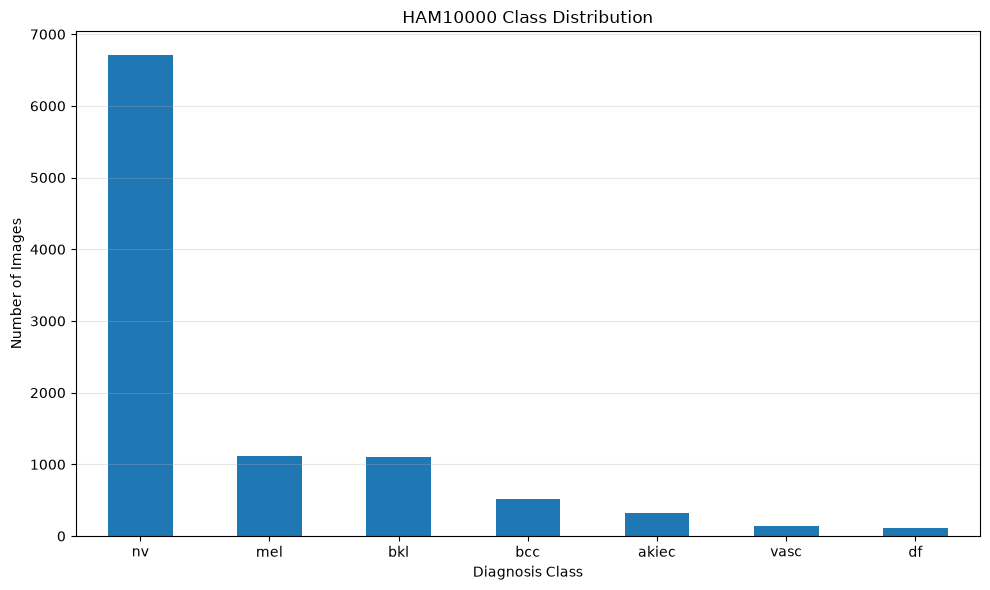

In [10]:
# Visualize class distribution
plt.figure(figsize=(10, 6))

class_counts.sort_values(ascending=False).plot(kind="bar")

plt.title("HAM10000 Class Distribution")
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

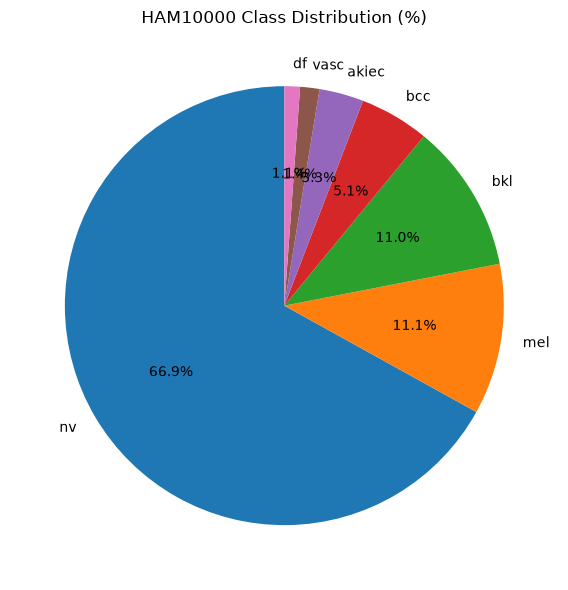

In [11]:
# Class distribution in percentage
plt.figure(figsize=(6, 6))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("HAM10000 Class Distribution (%)")

plt.tight_layout()
plt.show()

### 3. Class Imbalance 


In [12]:
# Calculate imbalance ratio
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print(f"Majority class : {majority_class} ({majority_count:,} images)")
print(f"Minority class : {minority_class} ({minority_count:,} images)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Majority class : nv (6,705 images)
Minority class : df (115 images)
Imbalance ratio: 58.30:1


### 4. Missing Values


In [13]:
# Summary missing values
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
age,57,0.569146
lesion_id,0,0.000000
dx,0,0.000000
image_id,0,0.000000
dx_type,0,0.000000
sex,0,0.000000
localization,0,0.000000
diagnosis_name,0,0.000000


### 5. Duplicate checking

In [14]:
# Image duplication check
duplicate_image_ids = df["image_id"].duplicated().sum()

print("Duplicate image_id:", duplicate_image_ids)

Duplicate image_id: 0


In [15]:
# Lession duplication check
lesion_counts = df["lesion_id"].value_counts()

print(f"Total images           : {len(df):,}")
print(f"Unique lesion IDs      : {df['lesion_id'].nunique():,}")

print(
    "Lesions with >1 image :",
    (lesion_counts > 1).sum()
)

print(
    "Maximum images for one lesion:",
    lesion_counts.max()
)

Total images           : 10,015
Unique lesion IDs      : 7,470
Lesions with >1 image : 1956
Maximum images for one lesion: 6


In [16]:
# Distribution of images per lesion
lesion_image_distribution = (
    lesion_counts
    .value_counts()
    .sort_index()
)

lesion_image_distribution

count
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64

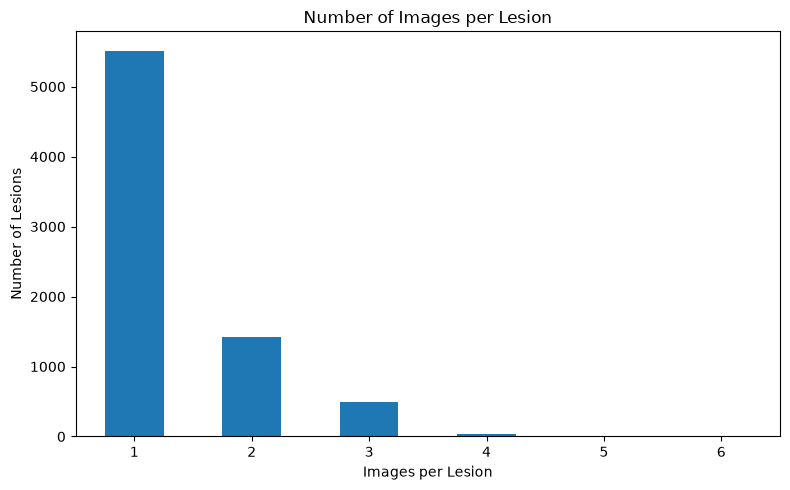

In [17]:
# Visualize lesion image distribution
plt.figure(figsize=(8, 5))

lesion_image_distribution.plot(kind="bar")

plt.title("Number of Images per Lesion")
plt.xlabel("Images per Lesion")
plt.ylabel("Number of Lesions")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### 6. Diagnosis Confirmation Type

In [18]:
# Inspect dx_type
dx_type_counts = df["dx_type"].value_counts()

dx_type_counts

dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

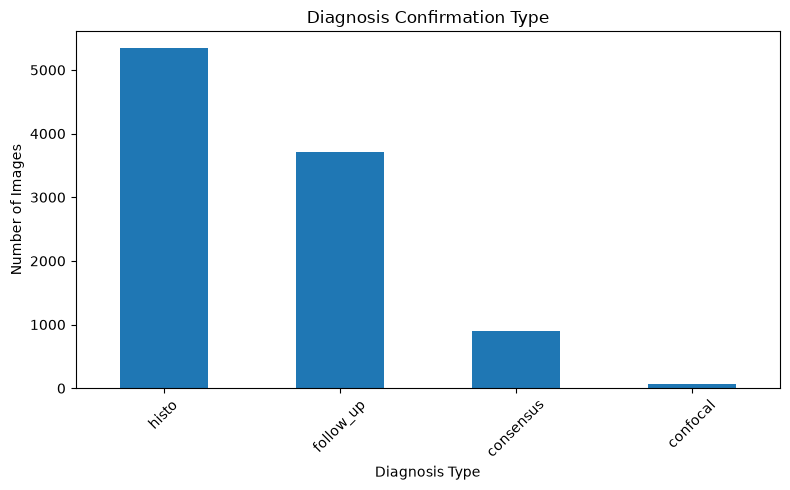

In [19]:
# Visualize diagnosis confirmation methods
plt.figure(figsize=(8, 5))

dx_type_counts.plot(kind="bar")

plt.title("Diagnosis Confirmation Type")
plt.xlabel("Diagnosis Type")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# Percentage of diagnosis confirmation methods
dx_type_distribution = pd.DataFrame({
    "count": df["dx_type"].value_counts(),
    "percentage": df["dx_type"].value_counts(normalize=True) * 100
})

dx_type_distribution

,count,percentage
dx_type,,
histo,5340,53.320020
follow_up,3704,36.984523
consensus,902,9.006490
confocal,69,0.688967


### 7. Demographics Analysis


In [21]:
# Age statistics
df["age"].describe()

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

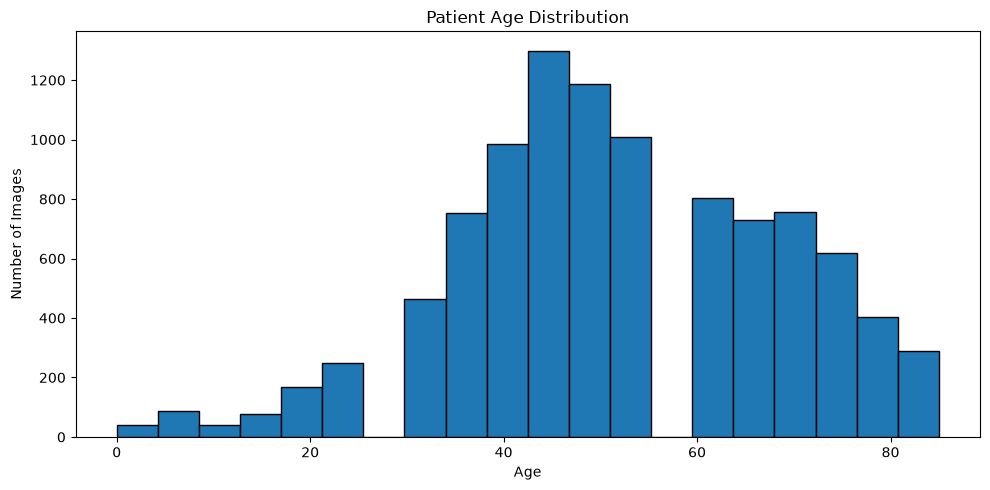

In [22]:
# Age distribution
plt.figure(figsize=(10, 5))

plt.hist(
    df["age"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [23]:
# Sex distribution
sex_counts = df["sex"].value_counts(dropna=False)

sex_counts

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

### 8. Lesion Localization

In [24]:
# Localization distribution
localization_counts = df["localization"].value_counts(dropna=False)

localization_counts

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

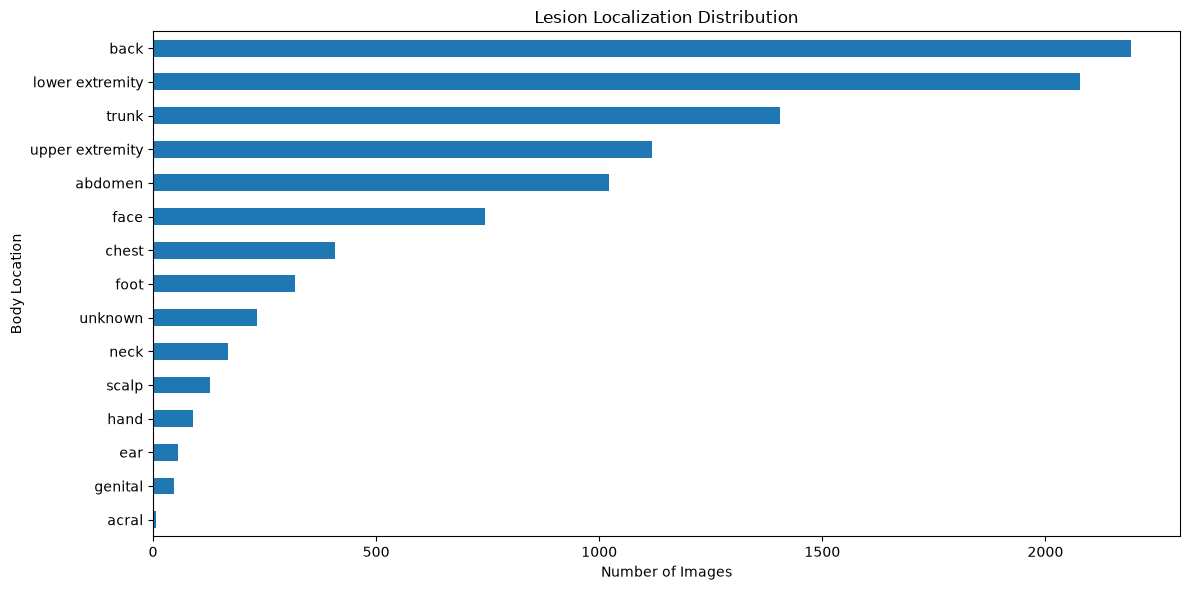

In [25]:
plt.figure(figsize=(12, 6))

localization_counts.sort_values().plot(kind="barh")

plt.title("Lesion Localization Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Body Location")

plt.tight_layout()

plt.show()

### 9. Image File Understanding

In [26]:
# Collect unique image file paths
image_paths = list(RAW_DATA_DIR.rglob("*.jpg"))

print(f"Number of image files found: {len(image_paths):,}")

image_paths[:5]

Number of image files found: 10,015


[WindowsPath('c:/Deep Learning/skin-lesion-classification/data/raw/HAM10000_images_part_1/ISIC_0024306.jpg'),
 WindowsPath('c:/Deep Learning/skin-lesion-classification/data/raw/HAM10000_images_part_1/ISIC_0024307.jpg'),
 WindowsPath('c:/Deep Learning/skin-lesion-classification/data/raw/HAM10000_images_part_1/ISIC_0024308.jpg'),
 WindowsPath('c:/Deep Learning/skin-lesion-classification/data/raw/HAM10000_images_part_1/ISIC_0024309.jpg'),
 WindowsPath('c:/Deep Learning/skin-lesion-classification/data/raw/HAM10000_images_part_1/ISIC_0024310.jpg')]

In [27]:
# Compare image file paths with metadata
image_ids_from_files = {
    path.stem for path in image_paths
}

metadata_image_ids = set(df["image_id"])

missing_images = metadata_image_ids - image_ids_from_files
extra_images = image_ids_from_files - metadata_image_ids

print(f"Images in metadata       : {len(metadata_image_ids):,}")
print(f"Image files found        : {len(image_ids_from_files):,}")

print(f"\nMissing image files      : {len(missing_images)}")
print(f"Images without metadata  : {len(extra_images)}")

Images in metadata       : 10,015
Image files found        : 10,015

Missing image files      : 0
Images without metadata  : 0


### 10. Image Size

In [28]:
# Inspect image dimensions
image_sizes = []

for path in image_paths:

    with Image.open(path) as img:
        image_sizes.append(img.size)

size_counts = Counter(image_sizes)

print(size_counts)

Counter({(600, 450): 10015})


### 11. Image Mode

In [29]:
image_modes = []

for path in image_paths[:500]:

    with Image.open(path) as img:
        image_modes.append(img.mode)

Counter(image_modes)

Counter({'RGB': 500})

### 12. Random Images

In [30]:
# Build image path mapping
IMAGE_PATH_MAP = {
    path.stem: path
    for path in image_paths
}

df["image_path"] = df["image_id"].map(IMAGE_PATH_MAP)

df[["image_id", "dx", "image_path"]].head()

,image_id,dx,image_path
0,ISIC_0027419,bkl,c:\Deep Learning\skin-lesion-classification\da...
1,ISIC_0025030,bkl,c:\Deep Learning\skin-lesion-classification\da...
2,ISIC_0026769,bkl,c:\Deep Learning\skin-lesion-classification\da...
3,ISIC_0025661,bkl,c:\Deep Learning\skin-lesion-classification\da...
4,ISIC_0031633,bkl,c:\Deep Learning\skin-lesion-classification\da...


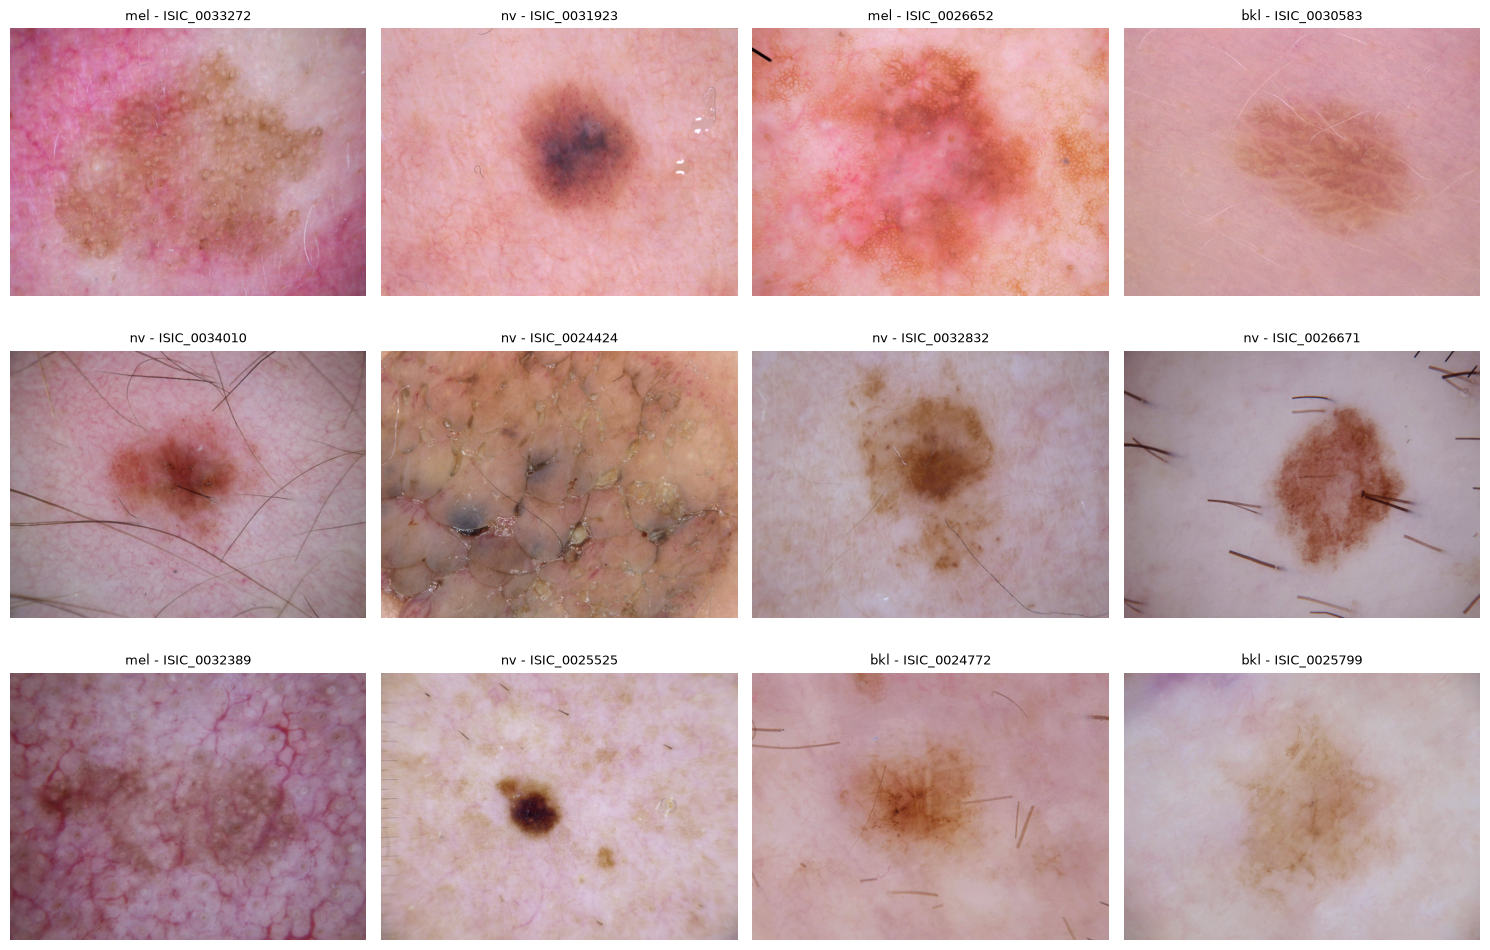

In [31]:
# Visualize random sample of images
sample_df = df.sample(12, random_state=42)

plt.figure(figsize=(15, 10))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):

    image = Image.open(row["image_path"])

    plt.subplot(3, 4, i)

    plt.imshow(image)

    plt.title(
        f"{row['dx']} - {row['image_id']}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### 13. Samples for Each Class

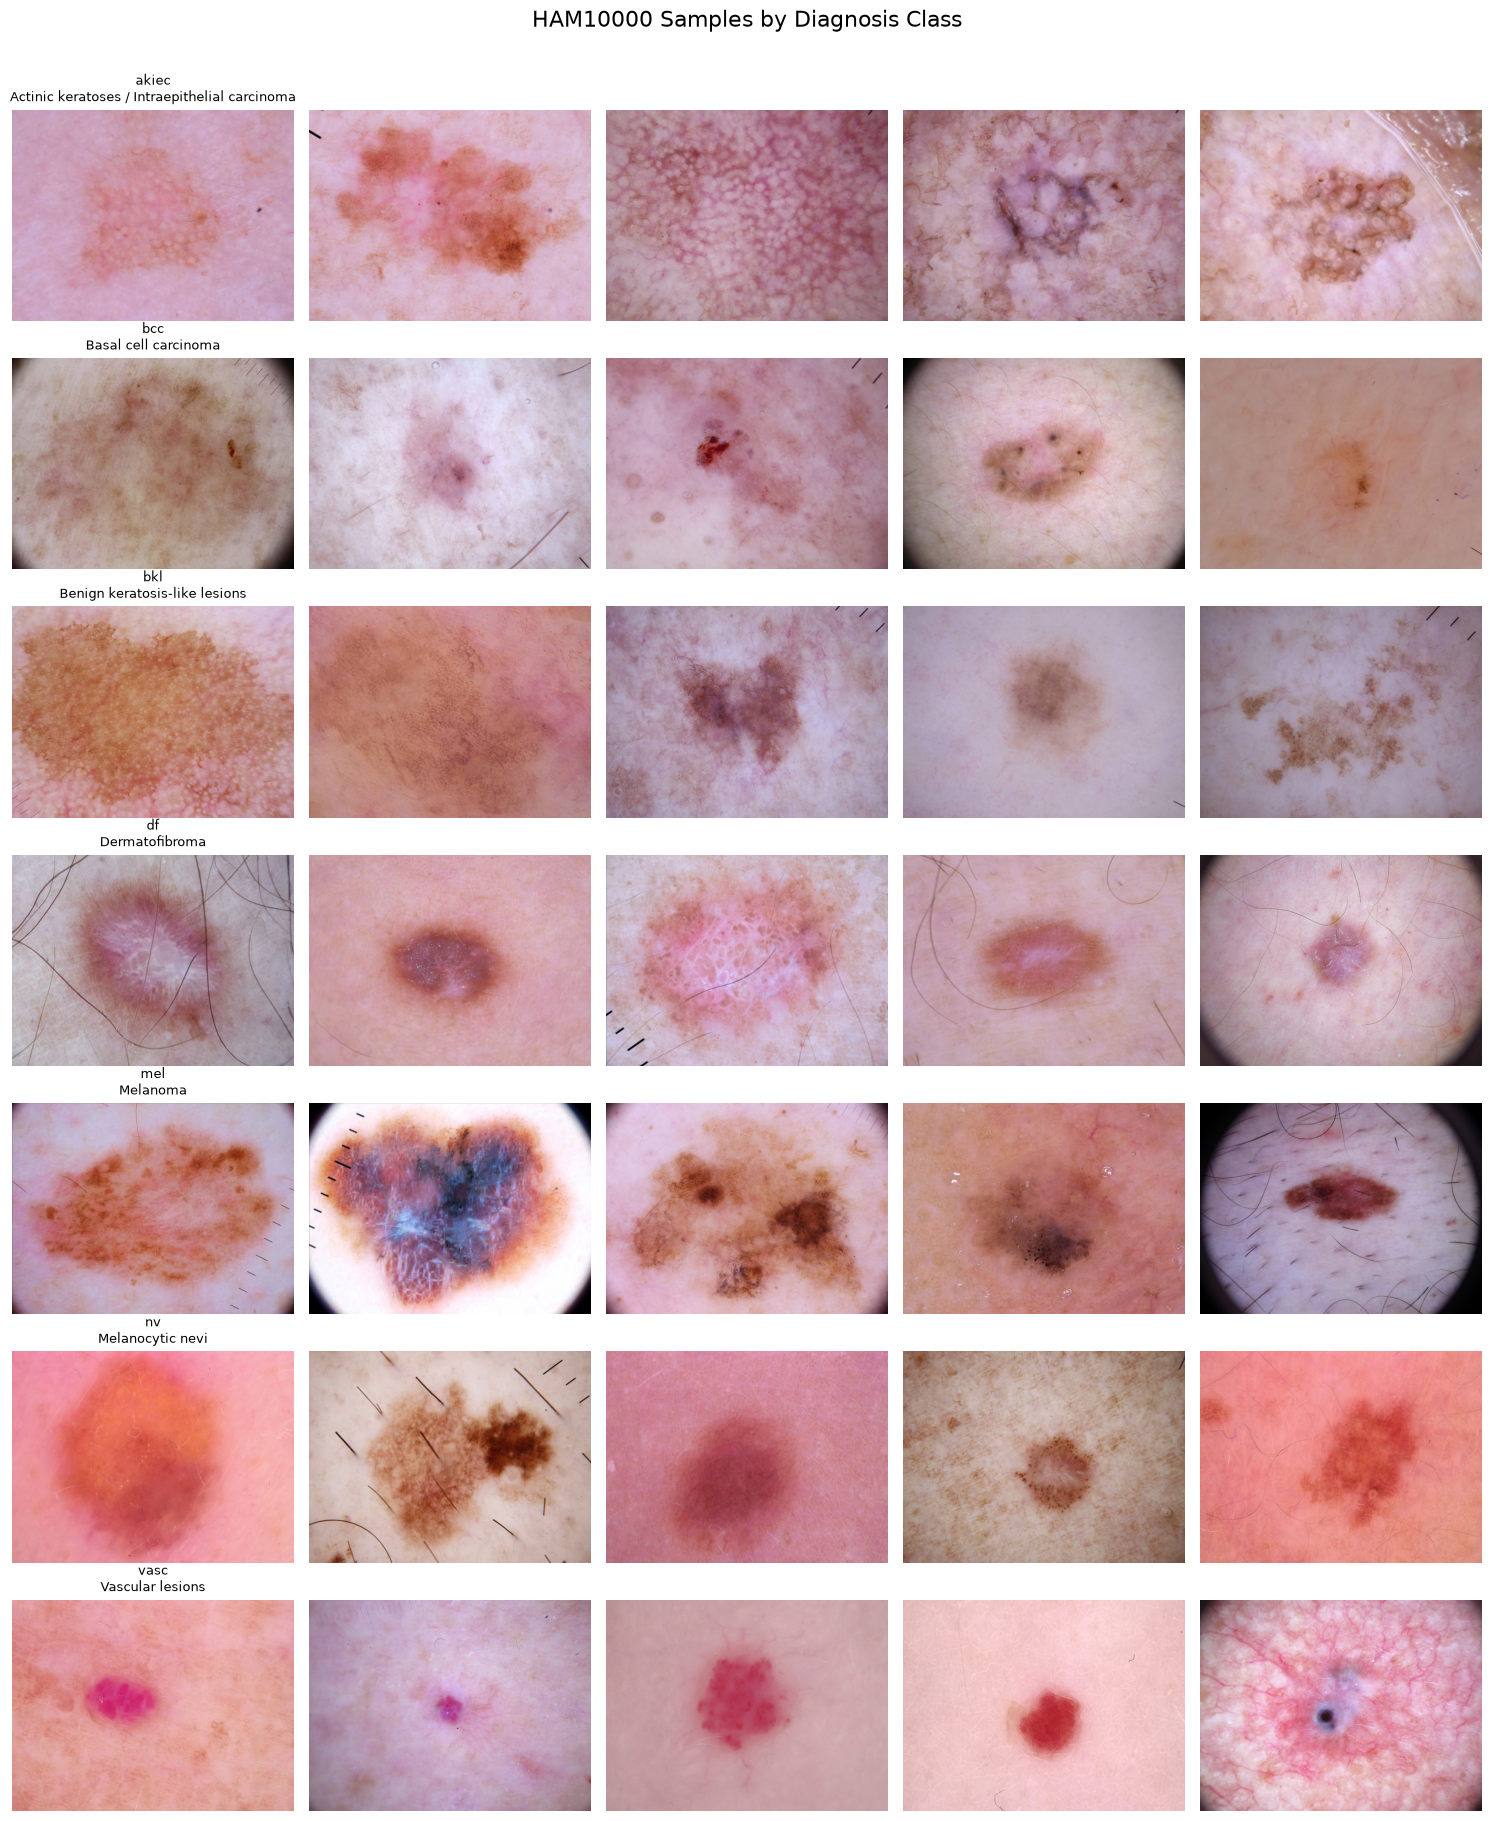

In [32]:
NUM_IMAGES_PER_CLASS = 5

classes = sorted(df["dx"].unique())

fig, axes = plt.subplots(
    len(classes),
    NUM_IMAGES_PER_CLASS,
    figsize=(15, 18)
)

for row_idx, class_name in enumerate(classes):

    class_samples = (
        df[df["dx"] == class_name]
        .sample(
            NUM_IMAGES_PER_CLASS,
            random_state=42
        )
    )

    for col_idx, (_, row) in enumerate(class_samples.iterrows()):

        image = Image.open(row["image_path"])

        ax = axes[row_idx, col_idx]

        ax.imshow(image)
        ax.axis("off")

        if col_idx == 0:
            ax.set_title(
                f"{class_name}\n{CLASS_NAMES[class_name]}",
                fontsize=9
            )

plt.suptitle(
    "HAM10000 Samples by Diagnosis Class",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "samples_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 14. Image Statistics

In [33]:
sample_paths = image_paths[:500]

mean_pixels = []

for path in sample_paths:

    with Image.open(path) as img:

        image = np.asarray(img).astype(np.float32) / 255.0

        mean_pixels.append(
            image.mean(axis=(0, 1))
        )

mean_pixels = np.array(mean_pixels)

dataset_rgb_mean = mean_pixels.mean(axis=0)

print("Approximate RGB mean:")
print(f"R: {dataset_rgb_mean[0]:.4f}")
print(f"G: {dataset_rgb_mean[1]:.4f}")
print(f"B: {dataset_rgb_mean[2]:.4f}")

Approximate RGB mean:
R: 0.7826
G: 0.5378
B: 0.5622


### 15. Summary

In [34]:
num_images = len(df)
num_classes = df["dx"].nunique()
num_lesions = df["lesion_id"].nunique()

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_percentage = (
    class_counts.max() / len(df) * 100
)

minority_percentage = (
    class_counts.min() / len(df) * 100
)

print("=" * 70)
print("HAM10000 DATA UNDERSTANDING SUMMARY")
print("=" * 70)

print(f"""
Number of metadata records : {num_images:,}
Number of image files      : {len(image_paths):,}
Number of lesion classes   : {num_classes}
Number of unique lesions   : {num_lesions:,}

Target variable            : dx

Majority class:
    {majority_class}
    {class_counts.max():,} images
    {majority_percentage:.2f}%

Minority class:
    {minority_class}
    {class_counts.min():,} images
    {minority_percentage:.2f}%

Class imbalance ratio:
    {class_counts.max() / class_counts.min():.2f}:1

Missing image files:
    {len(missing_images)}

Images without metadata:
    {len(extra_images)}

Important observations:
1. The dataset is strongly imbalanced.
2. Some lesions contain multiple images.
3. Dataset splitting should therefore consider lesion_id.
4. Metadata contains demographic and lesion-location information.
5. Image preprocessing and augmentation will be required before training.
""")

HAM10000 DATA UNDERSTANDING SUMMARY

Number of metadata records : 10,015
Number of image files      : 10,015
Number of lesion classes   : 7
Number of unique lesions   : 7,470

Target variable            : dx

Majority class:
    nv
    6,705 images
    66.95%

Minority class:
    df
    115 images
    1.15%

Class imbalance ratio:
    58.30:1

Missing image files:
    0

Images without metadata:
    0

Important observations:
1. The dataset is strongly imbalanced.
2. Some lesions contain multiple images.
3. Dataset splitting should therefore consider lesion_id.
4. Metadata contains demographic and lesion-location information.
5. Image preprocessing and augmentation will be required before training.

